In [186]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split
from datetime import datetime
import numpy as np
import copy



# Getting the same results with train and train_manual_update
- Write torch.manual_seed(42) at the beginning of your notebook.
- Write torch.set_default_dtype(torch.double) at the beginning of your notebook to alleviate precision errors

In [187]:
torch.manual_seed(42)
torch.set_default_dtype(torch.double)


# Tasks
Load, analyse and preprocess the CIFAR-10 dataset. Split it into 3
datasets: training, validation and test. Take a subset of these datasets
by keeping only 2 labels: bird and plane

In [188]:
def load_cifar(train_val_split=0.9, data_path='../data/', preprocessor=None):
    if preprocessor  is None:
        preprocessor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4915, 0.4823, 0.4468),
                                 (0.2470, 0.2435, 0.2616))
        ])
    
    # load datasets
    data_train_val = datasets.CIFAR10(
        data_path,       
        train=True,      
        download=True,  
        transform=preprocessor)

    data_test = datasets.CIFAR10(
        data_path, 
        train=False,
        download=True,
        transform=preprocessor)

    # Split the data into training and validation sets based on the train_val_split ratio
    n_train = int(len(data_train_val) * train_val_split)
    n_val =  len(data_train_val) - n_train

    data_train, data_val = random_split(
        data_train_val, 
        [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )

    print(f"Train size: {len(data_train)}")
    print(f"Validation size: {len(data_val)}")
    print(f"Test size: {len(data_test)}")

    label_map = {0: 0, 2: 1}
    class_names = ['airplane', 'bird']

    # For each part of dataset, keep only airplanes and birds. it means that we create new datasets 
    #(cifar2_train, cifar2_val, and cifar2_test) by filtering the original datasets (cifar10_train, cifar10_val, 
    # and cifar10_test) to only include the selected classes (0 and 2) and mapping their labels using label_map.
    #training data set:
    cifar2_train = [(img, label_map[label]) for img, label in data_train if label in [0, 2]]
    cifar2_val = [(img, label_map[label]) for img, label in data_val if label in [0, 2]]
    cifar2_test = [(img, label_map[label]) for img, label in data_test if label in [0, 2]]

    print(f"Train size: {len(cifar2_train)}")
    print(f"Validation size: {len(cifar2_val)}")
    print(f"Test size: {len(cifar2_test)}")

    
    
    return (cifar2_train, cifar2_val, cifar2_test)

cifar2_train, cifar2_val, cifar2_test = load_cifar()


def compute_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += data.size(0)
    return correct / total

Files already downloaded and verified


/opt/miniconda3/envs/INF265/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Train size: 45000
Validation size: 5000
Test size: 10000
Train size: 8980
Validation size: 1020
Test size: 2000


Write a MyMLP class that implements a MLP in PyTorch (so only fully
connected layers) such that:
    
    - The input dimension is 768(= 16 ∗ 16 ∗ 3) and the output dimension is 2 (for the 2 classes).
    - The hidden layers have respectively 128 and 32 hidden units.
    - All activation functions are ReLU. The last layer has no activation function since the cross-entropy loss already includes a softmax activation
function.

In [189]:
class MyNet(nn.Module):
    def __init__(self, hidden_sizes=None, dropout_rate=0):
        super(MyNet, self).__init__()
        if hidden_sizes is None:
            hidden_sizes = [512, 256, 128, 64, 32]

        layers = []
        in_features = 3072

        for i in range(len(hidden_sizes)):
            h = hidden_sizes[i]
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_features = h

        layers.append(nn.Linear(in_features, 2))  # output layer

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = torch.flatten(x, 1)  # (B, 3, 32, 32) -> (B, 3072)
        return self.network(x)

Write a train(n_epochs, optimizer, model, loss_fn, train_loader) function that trains model for n_epochs epochs given an optimizer optimizer, a loss function loss_fn and a dataloader train_loader.

In [190]:
def train(n_epochs, optimizer, model, loss_fn, train_loader, val_loader=None):
    # train
    model.train()
    train_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        running_train_loss = 0.0
        n_batches = 0
        for data, target in train_loader:
            data = data.view(data.size(0), -1)  # flatten
            output = model(data)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(output, target)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            n_batches += 1

        avg_train_loss = running_train_loss / n_batches
        train_losses.append(avg_train_loss)

        if val_loader is not None:
            # Validation phase
            model.eval()
            running_val_loss = 0.0
            n_batches = 0

            with torch.no_grad():
                for data, target in val_loader:
                    data = data.view(data.size(0), -1)
                    output = model(data)
                    val_loss = loss_fn(output, target)

                    running_val_loss += val_loss.item()
                    n_batches += 1

            avg_val_loss = running_val_loss / n_batches
            val_losses.append(avg_val_loss)

            if (epoch + 1) % 10 == 0:
                print(
                    f"Epoch {epoch+1}: "
                    f"Train loss = {train_losses[-1]:.4f}, "
                    f"Val loss = {avg_val_loss:.4f}"
                )
                
    return model, train_losses, val_losses

Write a similar function train manual_update that has no optimizer parameter, but a learning rate lr parameter instead and that manually updates each trainable parameter of model using equation (2). Do not forget to zero out all gradients after each iteration. 

Train 2 instances of MyMLP, one using train and the other using train_manual_update (use the same parameter values for both models). Compare their respective training losses. To get exactly the same results with both functions, see section 3.3

In [191]:
def train_manual_update(n_epochs, model, loss_fn, train_loader, lr=1e-2, momentum_coeff=0.0, weight_decay=0.0):
    model.train()
    velocity = {id(p): torch.zeros_like(p) for p in model.parameters() if p.requires_grad}
    losses = []

    for epoch in range(n_epochs):
        for data, target in train_loader:
            # forward
            data = data.view(data.size(0), -1)  # flatten if your model expects vectors
            output = model(data)
            loss = loss_fn(output, target)

            # backward
            loss.backward()

            # manual parameter update (equation 2: SGD step; extended with momentum + wd)
            with torch.no_grad():
                for p in model.parameters():
                    if not p.requires_grad:
                        continue
                    if p.grad is None:
                        continue

                    grad = p.grad

                    # weight decay (L2 regularization) in SGD: grad <- grad + wd * p
                    if weight_decay != 0.0:
                        grad = grad.add(p, alpha=weight_decay)

                    if momentum_coeff != 0.0:
                        v = velocity[id(p)]
                        v.mul_(momentum_coeff).add_(grad)   # v = mu*v + grad
                        p.add_(v, alpha=-lr)                # p = p - lr*v
                    else:
                        p.add_(grad, alpha=-lr)             # p = p - lr*grad

                    # zero grad for next iteration
                    p.grad = None

            losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {losses[-1]:.4f}")
        

    return model, losses

# Comparison of train vs train_manual_update and their respective losses

In [192]:
def comparison(weight_decay=0.0, momentum_coeff=0.0):
    model = MyNet()
    model2 = copy.deepcopy(model)

    optimizer = optim.SGD(model.parameters(), lr=1e-2, weight_decay=weight_decay, momentum=momentum_coeff)
    loss_fn = nn.CrossEntropyLoss()
    train_loader = torch.utils.data.DataLoader(cifar2_train, batch_size=64, shuffle=False)
    epochs = 5

    model, losses, _ = train(epochs, optimizer, model, loss_fn, train_loader)
    model2, losses2 = train_manual_update(epochs, model2, loss_fn, train_loader, weight_decay=weight_decay, momentum_coeff=momentum_coeff)

    comparison = losses == losses2
    return comparison

In [193]:
comparison1 = comparison()
comparison2 = comparison(weight_decay=1e-4)
comparison3 = comparison(weight_decay=1e-4, momentum_coeff=0.9)
print("Comparison without weight decay and momentum:", comparison1)
print("Comparison with weight decay:", comparison2)
print("Comparison with weight decay and momentum:", comparison3)

Comparison without weight decay and momentum: False
Comparison with weight decay: False
Comparison with weight decay and momentum: False


# Pipeline

## Visualizations

In [194]:
CIFAR_MEAN = torch.tensor([0.4915, 0.4823, 0.4468]).view(3, 1, 1)
CIFAR_STD  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

def unnormalize(img):
    """
    img: torch.Tensor of shape (3, H, W), normalized
    returns: torch.Tensor in [0,1]
    """
    img = img * CIFAR_STD + CIFAR_MEAN
    return img.clamp(0, 1)

In [195]:
import matplotlib.pyplot as plt

def display_images_norm_vs_unnorm(data_set, save=False):
    fig, axes = plt.subplots(8, 4, constrained_layout=True, figsize=(8, 10))
    fig.suptitle("Normalized vs Unnormalized (Planes = 0, Birds = 1)")

    it = iter(data_set)

    col_titles = ["Norm Plane", "Unnorm Plane", "Norm Bird", "Unnorm Bird"]
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title)

    for i in range(8):
        for cls in [0, 1]:
            while True:
                img, label = next(it)
                label = int(label.item()) if hasattr(label, "item") else int(label)
                if label == cls:
                    break

            # normalized image (for display we still need CHW -> HWC)
            img_norm = img.permute(1, 2, 0).cpu().numpy()

            # unnormalized image
            img_unnorm = unnormalize(img)
            img_unnorm = img_unnorm.permute(1, 2, 0).cpu().numpy()

            col = 2 * cls
            axes[i, col].imshow(img_norm)
            axes[i, col + 1].imshow(img_unnorm)

            axes[i, col].axis("off")
            axes[i, col + 1].axis("off")

    if save:
        plt.savefig("imgs/norm_vs_unnorm.png", dpi=200)
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9104945621973486..2.0397253702704323].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8787409700722393..1.5150506685854772].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.402437088195602..1.7399112550218865].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.402437088195602..1.005366672662949].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5612050488211477..1.6300309597523222].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.481821068508375..1.1252923187623676].
Clipping input data to the

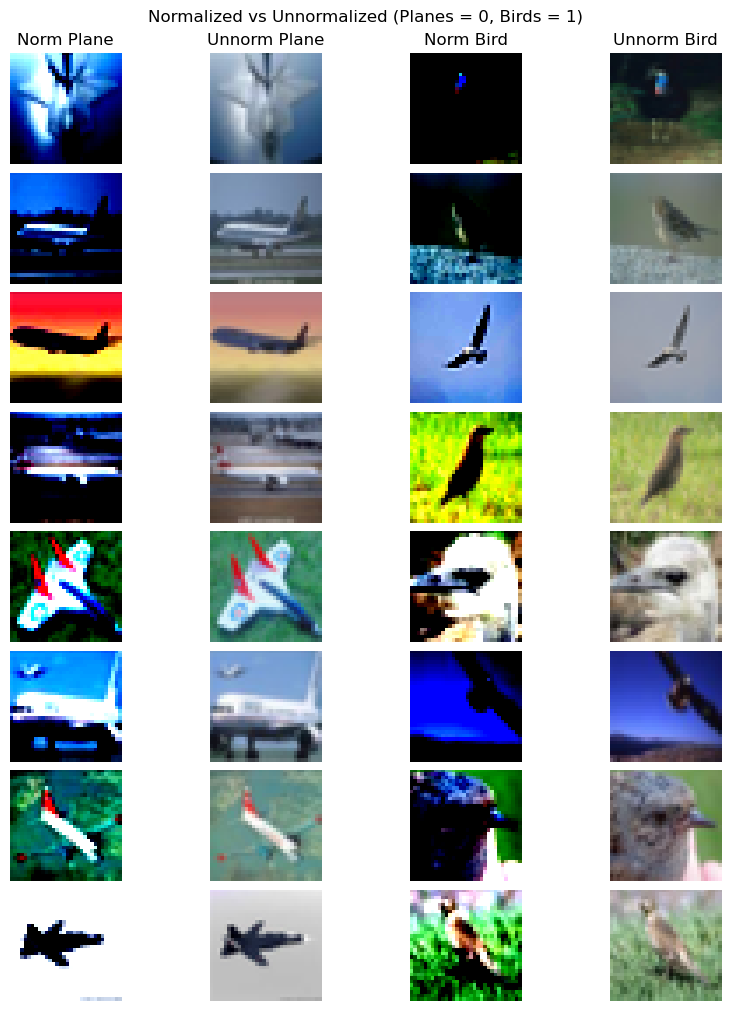

Class distribution: 
Label: 1 -> 4468 images
Label: 0 -> 4512 images


In [196]:
from collections import Counter

display_images_norm_vs_unnorm(cifar2_train, save=True)

print("Class distribution: ")
counter = Counter([label for _, label in cifar2_train])
for label, count in counter.items():
    print(f"Label: {label} -> {count} images")

## Model architecture optimalization

## 

In [197]:
# Øke hidden layers, øke dybden, legge til dropout layer

In [198]:
def evaluate_model():
    results = {}
    best_key = None
    best_score = float("inf")
    best_model = None
    
    torch.manual_seed(0)

    loss_fn = nn.CrossEntropyLoss()
    train_loader = torch.utils.data.DataLoader(cifar2_train, batch_size=64, shuffle=False)
    val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
    architecture = [
        {"name": "baseline", "hidden_sizes":[512, 128, 32]},
        {"name": "depth",    "hidden_sizes":[512, 256, 128, 64, 32]},
        {"name": "width",    "hidden_sizes":[1024, 128, 32]},
        {"name": "dropout",  "hidden_sizes":[512, 128, 32], "dropout_rate": 0.3}
    ]
    hyper_params = [
        {"lr": 0.01, "weight_decay": 0.0, "momentum": 0.0,},
        {"lr": 0.01, "weight_decay": 1e-4, "momentum": 0.9},
        {"lr": 0.01, "weight_decay": 0.0, "momentum": 0.9},
        {"lr": 0.01, "weight_decay": 0.01, "momentum": 0.9}
    ]
    epochs = 20
    

    for arch in architecture:
        for params in hyper_params:
            dropout = arch.get("dropout_rate", 0.0)

            model = MyNet(hidden_sizes=arch["hidden_sizes"], dropout_rate=dropout)

            optimizer = optim.SGD(model.parameters(), 
                                  lr=params["lr"], 
                                  weight_decay=params["weight_decay"], 
                                  momentum=params["momentum"])
            
            print(f"Training model with architecture: {arch}, hyperparameters: {params}, epochs: {epochs}, dropout_rate: {dropout}")
            model, train_losses, val_losses = train(epochs, optimizer, model, loss_fn, train_loader, val_loader)


            key = (arch["name"], tuple(arch["hidden_sizes"]), params["lr"], params["weight_decay"], params["momentum"], epochs, dropout)

            score = min(val_losses)

            results[key] = {
                    "train_losses": train_losses,
                    "val_losses": val_losses,
                    "best_val_loss": score,
                    "final_val_loss": val_losses[-1],
                }
            if score < best_score:
                best_score = score
                best_key = key
                best_model = model

    return results, best_key, best_model


results, best_key, best_model = evaluate_model()


Training model with architecture: {'name': 'baseline', 'hidden_sizes': [512, 128, 32]}, hyperparameters: {'lr': 0.01, 'weight_decay': 0.0, 'momentum': 0.0}, epochs: 20, dropout_rate: 0.0
Epoch 10: Train loss = 0.3272, Val loss = 0.4289
Epoch 20: Train loss = 0.1871, Val loss = 0.4305
Training model with architecture: {'name': 'baseline', 'hidden_sizes': [512, 128, 32]}, hyperparameters: {'lr': 0.01, 'weight_decay': 0.0001, 'momentum': 0.9}, epochs: 20, dropout_rate: 0.0
Epoch 10: Train loss = 0.1861, Val loss = 0.4527
Epoch 20: Train loss = 0.1068, Val loss = 0.6451
Training model with architecture: {'name': 'baseline', 'hidden_sizes': [512, 128, 32]}, hyperparameters: {'lr': 0.01, 'weight_decay': 0.0, 'momentum': 0.9}, epochs: 20, dropout_rate: 0.0
Epoch 10: Train loss = 0.1784, Val loss = 0.4965
Epoch 20: Train loss = 0.0889, Val loss = 0.5616
Training model with architecture: {'name': 'baseline', 'hidden_sizes': [512, 128, 32]}, hyperparameters: {'lr': 0.01, 'weight_decay': 0.01, 'm

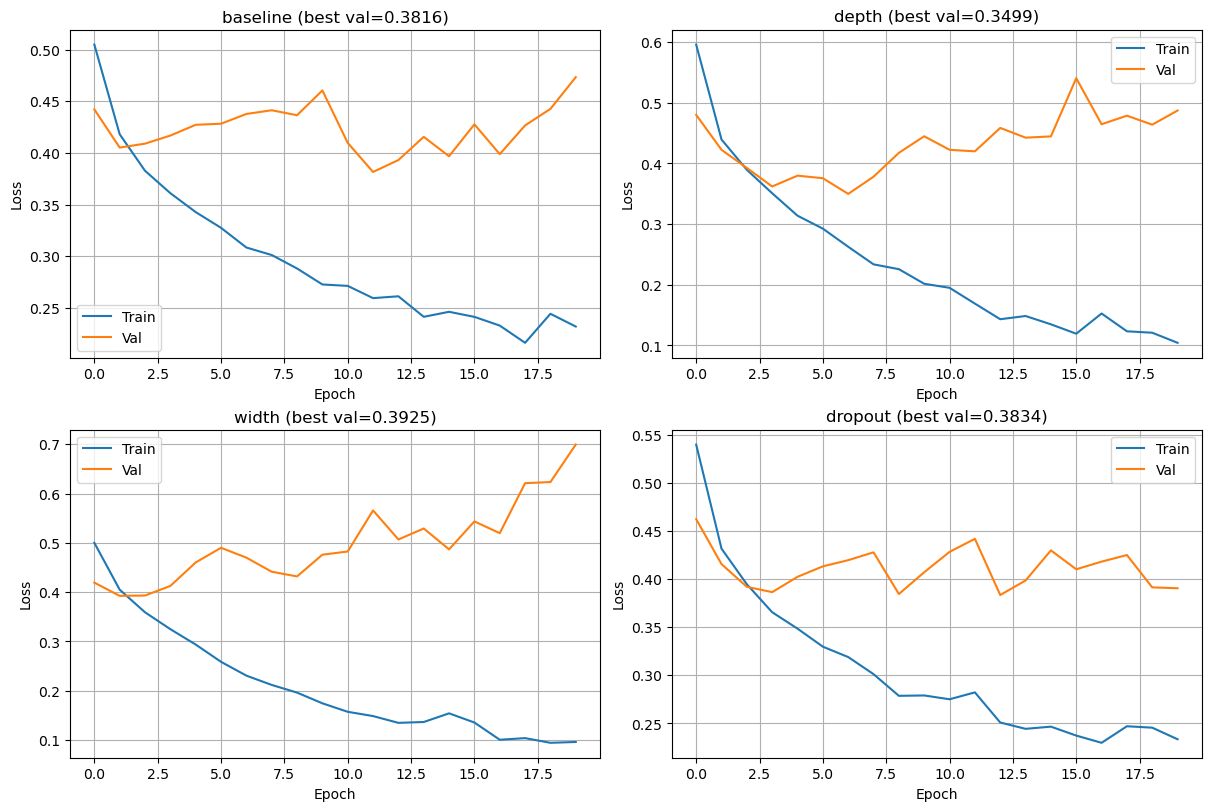

In [199]:
import matplotlib.pyplot as plt

def plot_best_per_arch(results):
    # group best run per architecture name
    best_by_arch = {}
    for key, info in results.items():
        arch_name = key[0]  # "baseline", "depth", ...
        score = info["best_val_loss"]
        if arch_name not in best_by_arch or score < best_by_arch[arch_name][1]:
            best_by_arch[arch_name] = (key, score)

    # fixed order for plotting
    order = ["baseline", "depth", "width", "dropout"]
    chosen = [(name, best_by_arch[name][0]) for name in order if name in best_by_arch]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    axes = axes.flatten()

    for ax, (arch_name, key) in zip(axes, chosen):
        tr = results[key]["train_losses"]
        va = results[key]["val_losses"]

        ax.plot(tr, label="Train")
        ax.plot(va, label="Val")
        ax.set_title(f"{arch_name} (best val={results[key]['best_val_loss']:.4f})")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend()

    # turn off unused axes if fewer than 4
    for ax in axes[len(chosen):]:
        ax.axis("off")

    plt.show()

plot_best_per_arch(results)


In [200]:
best_epoch = 1 + results[best_key]["val_losses"].index(min(results[best_key]["val_losses"]))
best_val = min(results[best_key]["val_losses"])
print(best_epoch, best_val, best_model)


7 0.3498795459303923 MyNet(
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [205]:
def correct_vs_wrong(model, loader):
    model.eval()
    correct = 0
    wrong = 0

    with torch.no_grad():
        for data, target in loader:
            data = data.view(data.size(0), -1)
            output = model(data)
            pred = output.argmax(dim=1)

            correct += (pred == target).sum().item()
            wrong += (pred != target).sum().item()

    return correct, wrong

In [206]:
val_loader = torch.utils.data.DataLoader(cifar2_test, batch_size=64, shuffle=False)
correct, wrong = correct_vs_wrong(best_model, val_loader)
print(f"Correct: {correct}, Wrong: {wrong}, Accuracy: {correct/(correct+wrong):.3f}")

Correct: 1691, Wrong: 309, Accuracy: 0.846


In [207]:
def confusion_matrix_binary(model, loader):
    model.eval()
    cm = np.zeros((2, 2), dtype=int)

    with torch.no_grad():
        for data, target in loader:
            data = data.view(data.size(0), -1)
            output = model(data)
            pred = output.argmax(dim=1)

            for t, p in zip(target, pred):
                cm[int(t), int(p)] += 1

    return cm

cm = confusion_matrix_binary(best_model, val_loader)
print("Confusion matrix:")
print(cm)

Confusion matrix:
[[848 152]
 [157 843]]


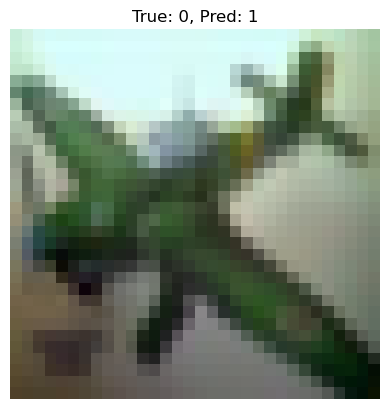

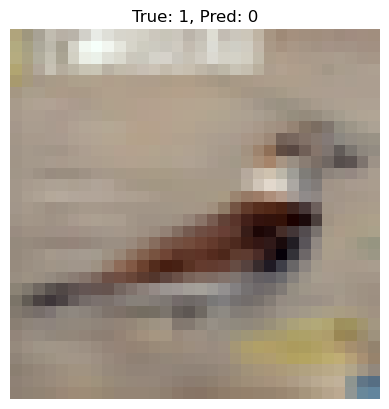

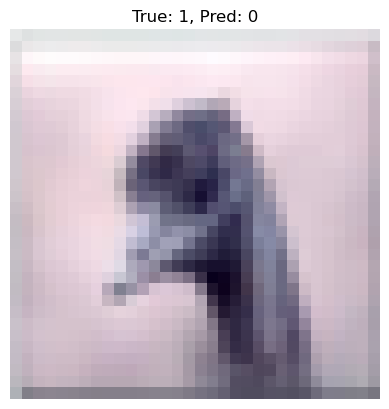

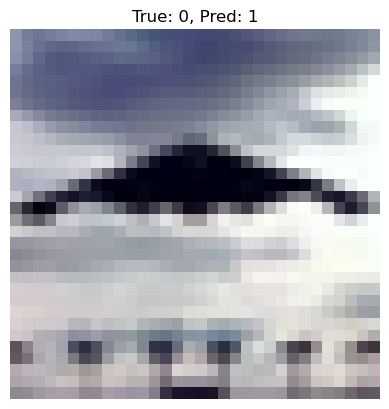

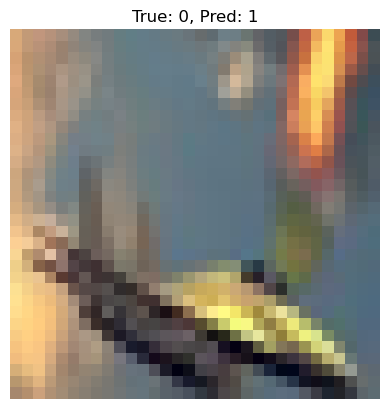

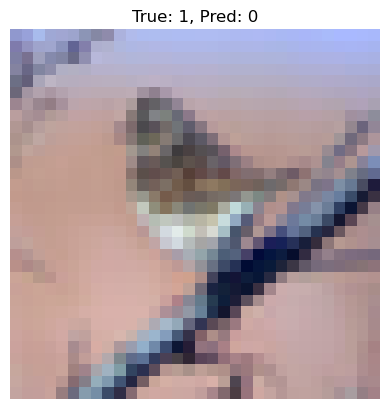

In [209]:
def show_misclassified(model, dataset, n=8):
    model.eval()
    shown = 0

    with torch.no_grad():
        for img, label in dataset:
            x = img.view(1, -1)
            output = model(x)
            pred = output.argmax(dim=1).item()

            if pred != label:
                # unnormalize for display
                img_disp = img.clone()
                img_disp = img_disp.permute(1, 2, 0).cpu().numpy()
                img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())

                plt.imshow(img_disp)
                plt.title(f"True: {label}, Pred: {pred}")
                plt.axis("off")
                plt.show()

                shown += 1
                if shown >= n:
                    break
show_misclassified(best_model, cifar2_test, n=6)